# REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# LOAD DATASET

In [2]:
df = pd.read_csv("/content/drive/MyDrive/train.csv")
df.head()


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


# CHECK DATA INFO

In [3]:
df.shape
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

,0
ID,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [4]:
df = df.dropna()


# ENCODE CATEGORICAL DATA

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


CHECKING


In [6]:
df.head()


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,0,0,0,0,7,0,6.351166,0,5,0
1,2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,25,0,2.255185,0,5,0
2,3,1,1,1,1,1,1,1,1,1,...,1,10,0,1,54,0,14.851484,0,5,1
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,54,0,2.276617,0,5,0
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,46,0,-4.777286,0,5,0


# SPLIT FEATURES & TARGET

In [7]:
X = df.drop('Class/ASD', axis=1)   # column name dataset-la irundha adjust pannunga
y = df['Class/ASD']


# TRAIN – TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# TRAIN MULTIPLE MODELS

**1**. Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_pred))

Logistic Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90       124
           1       0.68      0.64      0.66        36

    accuracy                           0.85       160
   macro avg       0.79      0.78      0.78       160
weighted avg       0.85      0.85      0.85       160


Confusion Matrix:
 [[113  11]
 [ 13  23]]


2. Decision **Tree**

In [10]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.81875


3. Random Forest (BEST)**bold text**

In [11]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.85


4. Support Vector **Machine**

In [12]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.775


5.**KNN**

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7625


# CONFUSION MATRIX (BEST MODEL)

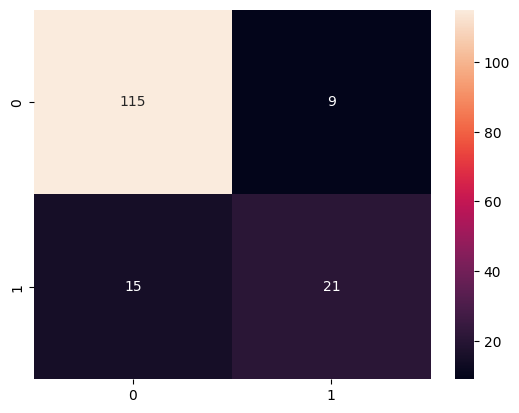

In [14]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


# CLASSIFICATION REPORT

In [15]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.88      0.93      0.91       124
           1       0.70      0.58      0.64        36

    accuracy                           0.85       160
   macro avg       0.79      0.76      0.77       160
weighted avg       0.84      0.85      0.84       160



# USER INPUT PREDICTION

In [16]:
sample = np.array([[1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 5.0, 1, 0, 0, 0, 0, 25, 0, 6.0, 0, 5]]) # Example with 21 features. Please replace these values with your actual input.
result = rf.predict(sample)

if result[0] == 1:
    print("Autism Detected")
else:
    print("No Autism")

No Autism


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
import pickle
pickle.dump(rf, open("autism_model.pkl", "wb"))




In [18]:
print(result)


[0]


In [19]:
sample = np.array([[1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 5.0, 1, 0, 0, 0, 0, 25, 0, 6.0, 0, 5]]) # This sample now has 21 features
result = rf.predict(sample)

print(result)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
X.shape


(800, 21)

In [21]:
X.columns



Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation'],
      dtype='object')

In [22]:
user_input = pd.DataFrame(
    [[1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 5.0, 1, 0, 0, 0, 0, 25, 0, 6.0, 0, 5]],
    columns=X.columns
)

In [23]:
result = rf.predict(user_input)

In [24]:
if result[0] == 1:
    print("Prediction Result: Autism Detected")
else:
    print("Prediction Result: No Autism Detected")

Prediction Result: No Autism Detected


In [25]:
import pickle
pickle.dump(rf, open("autism_model.pkl", "wb"))

In [26]:
import os
os.listdir()

['.config', 'autism_model.pkl', 'drive', 'sample_data']

In [27]:
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tpot



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.1/215.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00
  Created wheel for func-timeout: filename=func_ti

 **“The trained Random Forest model was successfully saved as a pickle file and verified by checking its presence in the working directory.”**

# Feature extraction

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)


In [29]:
X = df.drop('Class/ASD', axis=1)   # column name dataset-la irundha adjust pannunga
y = df['Class/ASD']

# Feature Importance (Tree-Based)

In [30]:
importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head()


,Feature,Importance
0,ID,0.121034
18,result,0.113637
11,age,0.102497
6,A6_Score,0.096060
4,A4_Score,0.095208


In [31]:
df = pd.read_csv("/content/drive/MyDrive/train.csv")
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [32]:
df = df.dropna()

In [33]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# SelectKBest (Statistical Method)

In [34]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Step 1: Scale X to non-negative values (0 to 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply SelectKBest
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(X_scaled, y)



# XGBoost

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=124/36,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# LightGBM

In [36]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 125, number of negative: 515
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000553 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42)

In [37]:
X.var().sort_values()


,0
age_desc,0.000000
used_app_before,0.058667
austim,0.137107
jaundice,0.177996
A6_Score,0.211751
gender,0.223874
A10_Score,0.236489
A5_Score,0.239274
A7_Score,0.239793
A4_Score,0.243079


# FIX 1 (BEST & SIMPLE): Tell LightGBM to be aggressive

In [38]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=15,
    min_child_samples=5,
    min_gain_to_split=0.0,
    max_depth=5,
    class_weight='balanced',
    force_row_wise=True,
    random_state=42
)

lgbm.fit(X_train, y_train)


NameError: name 'LGBMClassifier' is not defined

In [ ]:
X = df.drop(['Class/ASD', 'result', 'age_desc', 'ID'], axis=1)
y = df['Class/ASD']
